# Challenge A

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

Linear LSQ - MSE: 7.6679, R2: 0.0681
Cubic Polyfit - MSE: 6.6438, R2: 0.1926
The better fit is: Cubic Polyfit


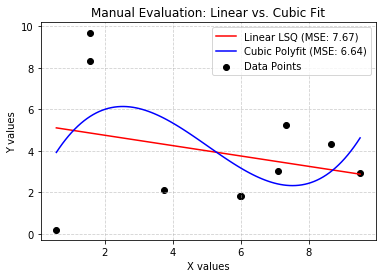

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data (Randomized but sorted X)
np.random.seed(42) 
x_values = 10 * np.sort(np.random.rand(10))
y_values = 10 * np.random.rand(10)

# --- Method 1: Linear Least Squares (Degree 1) ---
A = np.vstack([x_values, np.ones(len(x_values))]).T
m, c = np.linalg.lstsq(A, y_values, rcond=None)[0]
y_pred_lsq = m * x_values + c

# --- Method 2: Cubic Polyfit (Degree 3) ---
poly_coeffs = np.polyfit(x_values, y_values, 3)
p_cubic = np.poly1d(poly_coeffs)
y_pred_poly = p_cubic(x_values)

# --- Manual Metric Calculation Function ---
def calculate_metrics(y_true, y_pred):
    # Mean Squared Error
    mse = np.mean((y_true - y_pred)**2)
    
    # R-Squared
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return mse, r2

# Calculate for both methods
mse_lsq, r2_lsq = calculate_metrics(y_values, y_pred_lsq)
mse_poly, r2_poly = calculate_metrics(y_values, y_pred_poly)

# Determine better fit
better_method = "Cubic Polyfit" if mse_poly < mse_lsq else "Linear Least Squares"

# 2. Visualization
plt.scatter(x_values, y_values, color='black', label='Data Points')

# Create a smooth line for the curves
x_range = np.linspace(x_values.min(), x_values.max(), 100)
plt.plot(x_range, m * x_range + c, color='red', label=f'Linear LSQ (MSE: {mse_lsq:.2f})')
plt.plot(x_range, p_cubic(x_range), color='blue', label=f'Cubic Polyfit (MSE: {mse_poly:.2f})')

plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Manual Evaluation: Linear vs. Cubic Fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('manual_comparison.png')

# 3. Print evaluation
print(f"Linear LSQ - MSE: {mse_lsq:.4f}, R2: {r2_lsq:.4f}")
print(f"Cubic Polyfit - MSE: {mse_poly:.4f}, R2: {r2_poly:.4f}")
print(f"The better fit is: {better_method}")

# Challenge B

In [8]:
# 1. Setup Data
np.random.seed(42)
x_values = 10 * np.sort(np.random.rand(10))
y_values = 10 * np.random.rand(10)

def get_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    return mse, r2

# Define the degrees to test (Cranking up and down)
degrees = [1, 2, 3, 4, 5, 7, 9]

print(f"{'Degree':<8} | {'MSE':<12} | {'R2':<10}")
print("-" * 35)

for deg in degrees:
    # Fit and Predict
    coeffs = np.polyfit(x_values, y_values, deg)
    p = np.poly1d(coeffs)
    y_pred = p(x_values)
    
    # Evaluate
    mse, r2 = get_metrics(y_values, y_pred)
    print(f"{deg:<8} | {mse:<12.4f} | {r2:<10.4f}")

    # Plot logic (Optional visualization)
    # plt.plot(np.linspace(0, 10, 100), p(np.linspace(0, 10, 100)), label=f'Deg {deg}')

Degree   | MSE          | R2        
-----------------------------------
1        | 7.6679       | 0.0681    
2        | 7.5829       | 0.0785    
3        | 6.6438       | 0.1926    
4        | 1.1994       | 0.8542    
5        | 0.2658       | 0.9677    
7        | 0.0949       | 0.9885    
9        | 0.0000       | 1.0000    


# Challenge C

Degree 1 | MSE: 7.6679 | R2: 0.0681
Degree 3 | MSE: 6.6438 | R2: 0.1926
Degree 9 | MSE: 0.0000 | R2: 1.0000


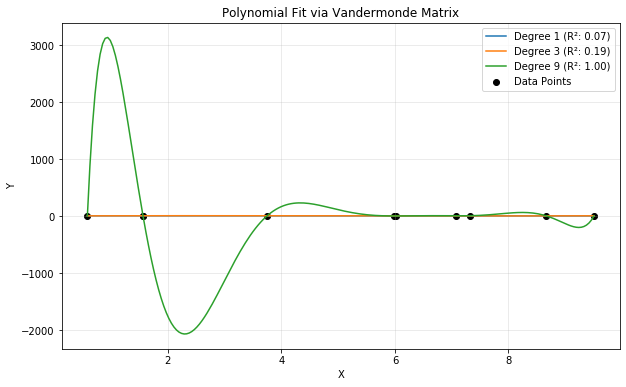

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the same data points
np.random.seed(42)
x_values = 10 * np.sort(np.random.rand(10))
y_values = 10 * np.random.rand(10)

def solve_via_vandermonde(x, y, degree):
    # Construct the Vandermonde Matrix (Manual way)
    # This creates columns: [x^n, x^(n-1), ..., x^1, x^0]
    V = np.vander(x, degree + 1)
    
    # Solve the normal equations: (V^T * V) * w = V^T * y
    # np.linalg.lstsq handles this robustly
    weights, residuals, rank, s = np.linalg.lstsq(V, y, rcond=None)
    
    # Create a prediction function using the weights
    # weights are in order: [a_n, a_n-1, ..., a_0]
    p = np.poly1d(weights)
    return p, weights

def get_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    return mse, r2

# 2. Evaluate different degrees
degrees = [1, 3, 9] # Linear, Cubic, and Blatant Overfit
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='black', label='Data Points')

x_plot = np.linspace(x_values.min(), x_values.max(), 200)

for d in degrees:
    poly_func, coeffs = solve_via_vandermonde(x_values, y_values, d)
    y_pred = poly_func(x_values)
    mse, r2 = get_metrics(y_values, y_pred)
    
    plt.plot(x_plot, poly_func(x_plot), label=f'Degree {d} (R²: {r2:.2f})')
    print(f"Degree {d} | MSE: {mse:.4f} | R2: {r2:.4f}")

plt.title("Polynomial Fit via Vandermonde Matrix")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()